In [1]:
import os, pickle, jax
os.chdir('..' if os.getcwd().endswith("/eugene") else '.')

jax.config.update('jax_platform_name', 'cpu')
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import pandas as pd
# from eugene.vae import VAE
from ilms.models.celeba_vae_prc import VAE
from flax import nnx
import matplotlib.pyplot as plt

import numpy as np

In [2]:
with open('eugene/best_model_69.pickle', 'rb') as file:
    model_dict = pickle.load(file)

model = VAE(rngs=nnx.Rngs(0))

model.opts = model_dict['opts']
model.stats = model_dict['stats']
nnx.update(model, model_dict['state'])

In [39]:
with open('eugene/geo_evals_seed4.pkl', 'rb') as file:
    a_dict = pickle.load(file)

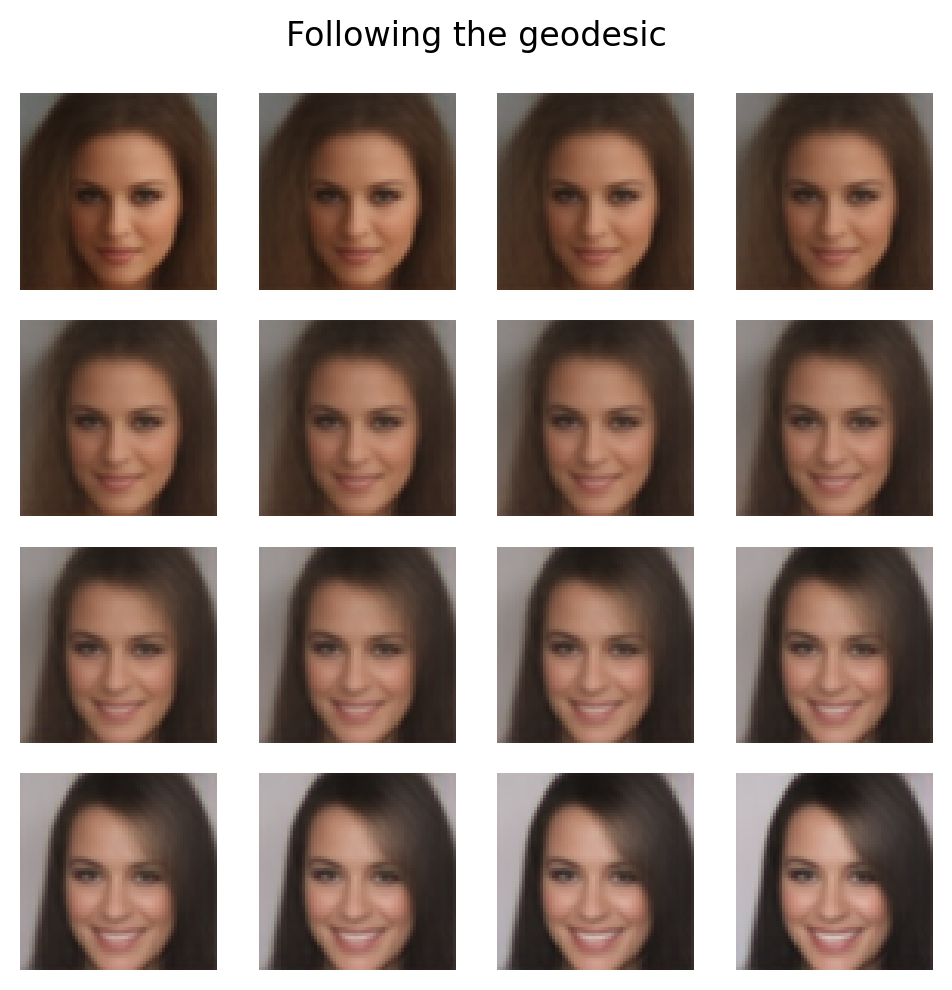

In [40]:
z_mu = a_dict['geo_evals'][0].T
x = nnx.vmap(lambda z, d: d(z), in_axes=(None, 0))(z_mu, model.decoder)
x = x.mean(axis=0)
x = x[::16]

# show 16 images from x
fig, axs = plt.subplots(4, 4, figsize=(5, 5))
fig.suptitle('Following the geodesic')
for i, ax in enumerate(axs.flatten()):
    plt.subplot(4, 4, i+1)
    plt.imshow(x[i], cmap='gray')
    plt.axis('off')

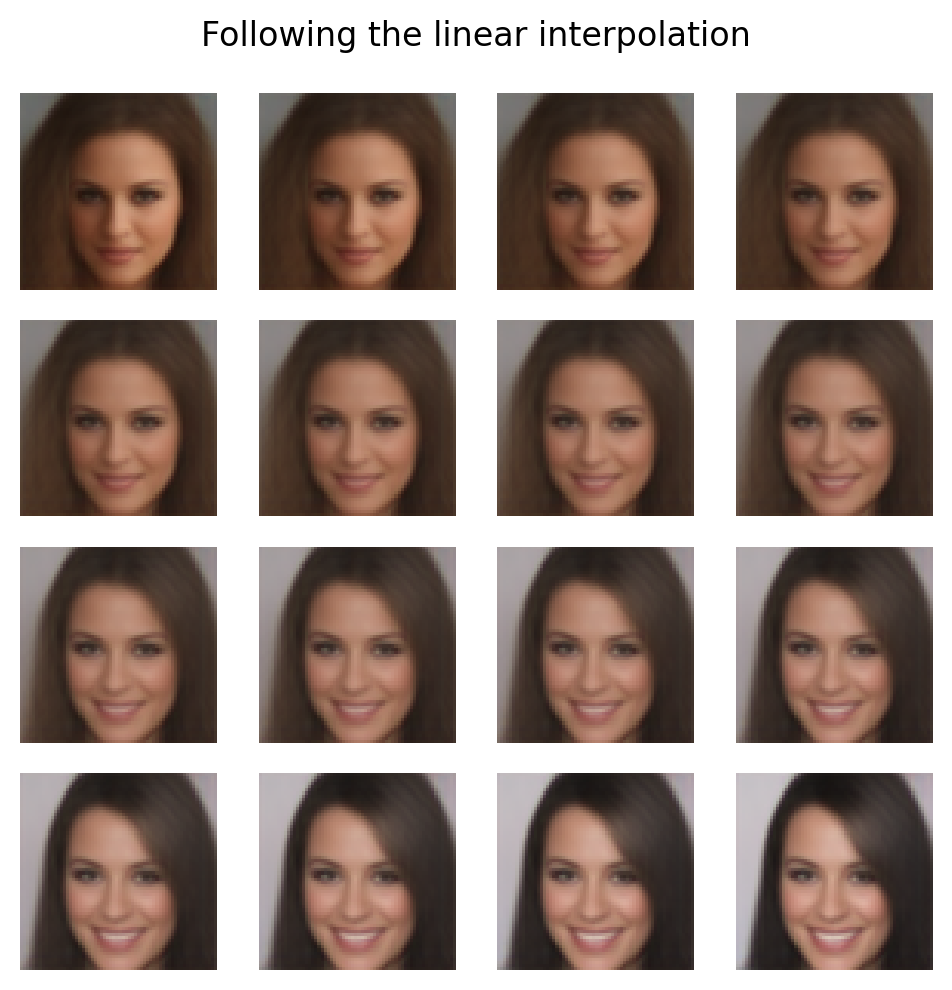

In [41]:
z_mu = a_dict['geo_eval_line'][0].T
x = nnx.vmap(lambda z, d: d(z), in_axes=(None, 0))(z_mu, model.decoder)
x = x.mean(axis=0)
x = x[::16]

# show 16 images from x
fig, axs = plt.subplots(4, 4, figsize=(5, 5))
fig.suptitle('Following the linear interpolation')
for i, ax in enumerate(axs.flatten()):
    plt.subplot(4, 4, i+1)
    plt.imshow(x[i], cmap='gray')
    plt.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.038168535..0.72691786].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.060471695..0.8737756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0030983165..0.82633984].


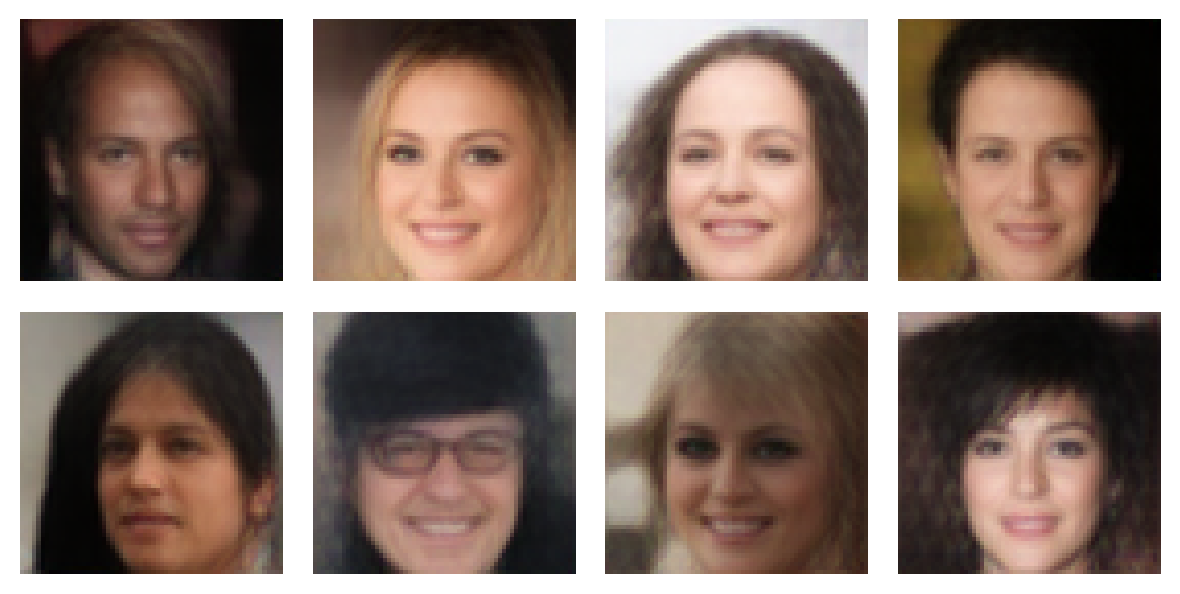

In [38]:
z = jax.random.normal(model.rngs(), (8, 64)) * 1.0
x = model.decode(z)#.transpose(0, 2, 1, 3)
# plot x as an image grid
plt.figure(figsize=(6, 6))
for i in range(8):
    plt.subplot(4, 4, i+1)
    plt.imshow(x[i], cmap='gray')
    plt.axis('off')

# plt.imshow(x[0]., cmap='gray')
# plt.grid(False)